# EDA – Streaming & Gaming Price Analysis
**COSC 482 | Spring 2026**

This notebook uses `shared_data.py` for data loading (no redundancy) and produces graphs + the CSV outputs consumed by the Dashboard.

In [12]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as scipy_stats
from Helpers import load_all, EDA_OUTPUT

plt.rcParams.update(
    {
        "figure.facecolor": "#0f1117",
        "axes.facecolor": "#1e2130",
        "axes.edgecolor": "#3a3f5c",
        "axes.labelcolor": "#c8cfe8",
        "xtick.color": "#8892b0",
        "ytick.color": "#8892b0",
        "text.color": "#e0e6ff",
        "grid.color": "#2e3555",
        "grid.linewidth": 0.5,
        "font.family": "sans-serif",
        "axes.titlecolor": "#e0e6ff",
        "axes.titlesize": 13,
    }
)
ACCENT = "#4da6ff"
PAL = ["#1DB954", "#4da6ff", "#F4B942", "#FF8C42", "#FF6B6B"]

data = load_all()
subs = data["subs"]
hourly = data["hourly"]
steam = data["steam"]
affordability = data["affordability"]

print(
    f"Subs: {subs.shape} | Hourly: {hourly.shape} | Steam: {steam.shape} | Affordability: {affordability.shape}"
)

Subs: (494, 7) | Hourly: (261, 3) | Steam: (10346, 10) | Affordability: (394, 11)


## 1. Pearson Correlation Matrix
Correlation between price, hourly wage, and hours needed to afford a subscription.

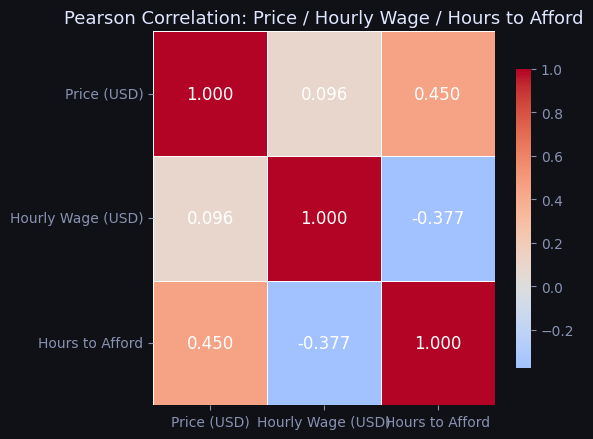

                   Price (USD)  Hourly Wage (USD)  Hours to Afford
Price (USD)             1.0000             0.0964           0.4503
Hourly Wage (USD)       0.0964             1.0000          -0.3766
Hours to Afford         0.4503            -0.3766           1.0000


In [13]:
corr_df = affordability[["price", "hourly_wage_usd", "hours_to_afford"]].copy()
corr_df.columns = ["Price (USD)", "Hourly Wage (USD)", "Hours to Afford"]
corr_matrix = corr_df.corr(method="pearson").round(4)
corr_matrix.to_csv(EDA_OUTPUT / "Pearson_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 12, "color": "white"},
)
ax.set_title("Pearson Correlation: Price / Hourly Wage / Hours to Afford")
plt.tight_layout()
plt.show()
print(corr_matrix)

## 2. Descriptive Statistics per Platform

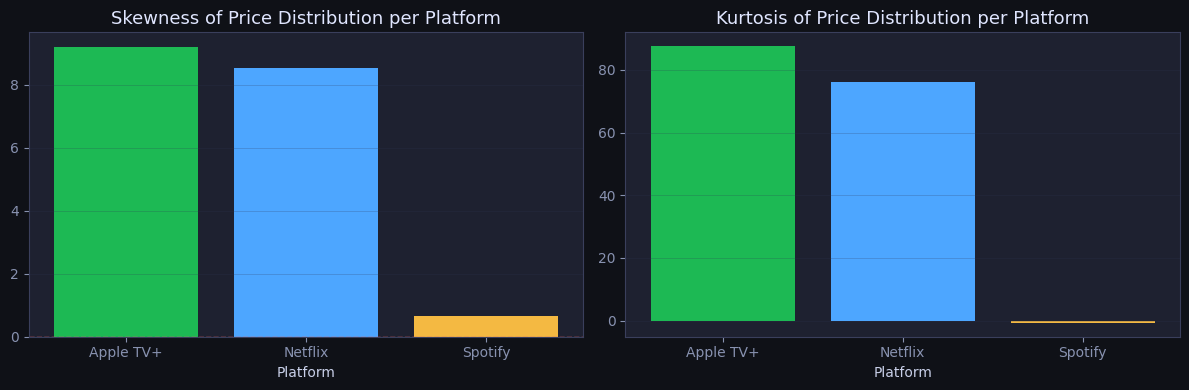

,Platform,Count,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
0,Apple TV+,103,12.587,12.99,15.994,2.50,169.0,9.2098,87.5693
1,Netflix,177,13.565,8.99,34.868,3.99,369.0,8.5357,76.1136
2,Spotify,114,12.444,9.49,7.448,1.52,30.5,0.6520,-0.7003


In [14]:
desc_rows = []
for plat, grp in affordability[affordability["price"] > 0].groupby("platform"):
    p = grp["price"].dropna()
    desc_rows.append(
        {
            "Platform": plat,
            "Count": len(p),
            "Mean": round(p.mean(), 3),
            "Median": round(p.median(), 3),
            "Std Dev": round(p.std(), 3),
            "Min": round(p.min(), 3),
            "Max": round(p.max(), 3),
            "Skewness": round(scipy_stats.skew(p), 4),
            "Kurtosis": round(scipy_stats.kurtosis(p), 4),
        }
    )
desc_df = pd.DataFrame(desc_rows)
desc_df.to_csv(EDA_OUTPUT / "Descriptive_stats_per_platform.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
platforms = desc_df["Platform"]
x = range(len(platforms))
axes[0].bar(platforms, desc_df["Skewness"], color=PAL[: len(platforms)])
axes[0].set_title("Skewness of Price Distribution per Platform")
axes[0].axhline(0, color="#FF6B6B", linestyle="--", lw=1)
axes[1].bar(platforms, desc_df["Kurtosis"], color=PAL[: len(platforms)])
axes[1].set_title("Kurtosis of Price Distribution per Platform")
for ax in axes:
    ax.set_xlabel("Platform")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
desc_df

## 3. Price Distribution by Platform

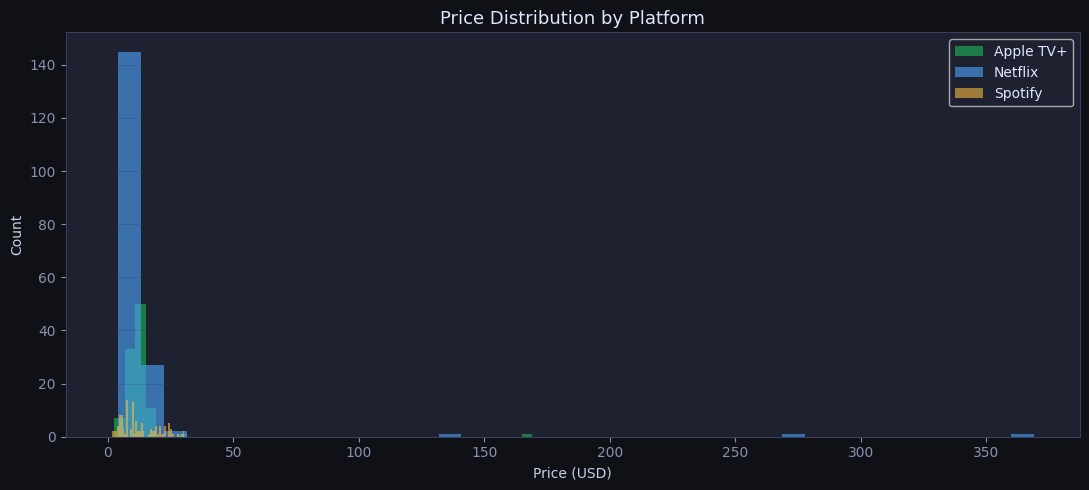

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
platforms_list = affordability["platform"].unique()
for i, plat in enumerate(platforms_list):
    prices = affordability[affordability["platform"] == plat]["price"]
    ax.hist(prices, bins=40, alpha=0.6, label=plat, color=PAL[i % len(PAL)])
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution by Platform")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. IQR Outlier Detection (Subscription Prices)

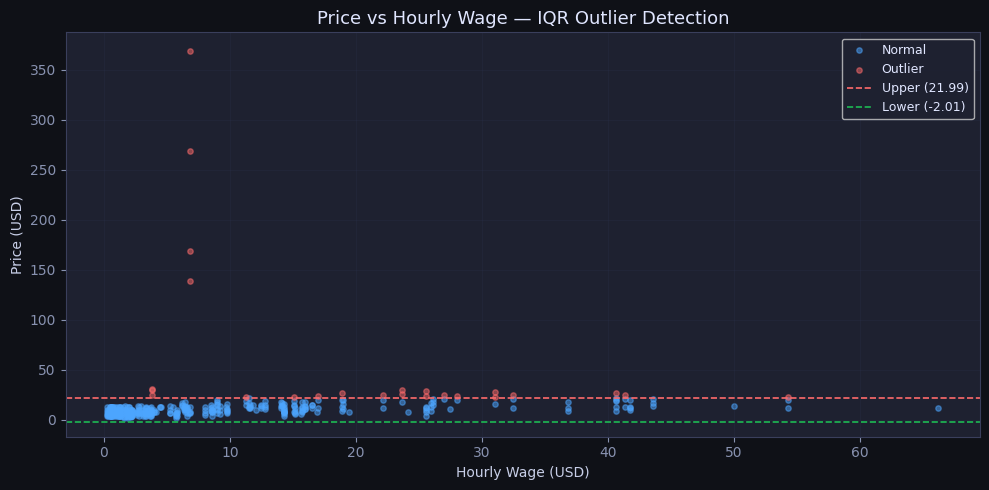

IQR bounds: Q1=6.99 | Q3=12.99 | IQR=6.00 | Lower=-2.01 | Upper=21.99
24 outliers out of 394 records (6.1%)


In [16]:
iqr_data = affordability[affordability["price"] > 0].copy()
Q1, Q3 = iqr_data["price"].quantile(0.25), iqr_data["price"].quantile(0.75)
IQR = Q3 - Q1
lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR
iqr_data["Outlier"] = iqr_data["price"].apply(
    lambda x: "Outlier" if x < lb or x > ub else "Normal"
)
iqr_data[
    ["region", "platform", "plan_tier", "price", "hourly_wage_usd", "Outlier"]
].to_csv(EDA_OUTPUT / "eda_iqr_outliers.csv", index=False)
json.dump(
    {"Q1": Q1, "Q3": Q3, "IQR": IQR, "lower": lb, "upper": ub},
    open(EDA_OUTPUT / "eda_iqr_bounds.json", "w"),
)

colours = {"Normal": ACCENT, "Outlier": "#FF6B6B"}
fig, ax = plt.subplots(figsize=(10, 5))
for label, grp in iqr_data.groupby("Outlier"):
    ax.scatter(
        grp["hourly_wage_usd"],
        grp["price"],
        alpha=0.5,
        s=15,
        c=colours[label],
        label=label,
    )
ax.axhline(ub, color="#FF6B6B", linestyle="--", lw=1.2, label=f"Upper ({ub:.2f})")
ax.axhline(lb, color="#1DB954", linestyle="--", lw=1.2, label=f"Lower ({lb:.2f})")
ax.set_xlabel("Hourly Wage (USD)")
ax.set_ylabel("Price (USD)")
ax.set_title("Price vs Hourly Wage — IQR Outlier Detection")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
n_out = (iqr_data["Outlier"] == "Outlier").sum()
print(
    f"IQR bounds: Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f} | Lower={lb:.2f} | Upper={ub:.2f}"
)
print(
    f"{n_out} outliers out of {len(iqr_data)} records ({n_out/len(iqr_data)*100:.1f}%)"
)

## 5. Hourly Wage by Global Quartile

C:\Users\Bahaa Rawass\AppData\Local\Temp\ipykernel_4312\685616282.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


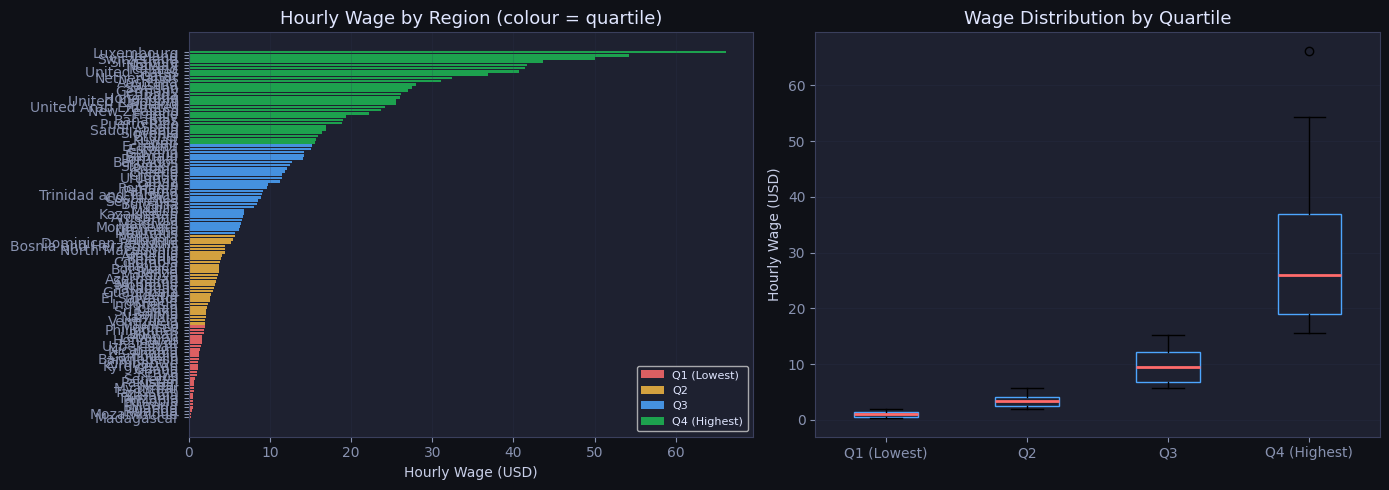

In [17]:
wage_df = affordability.drop_duplicates("region")[
    ["region", "hourly_wage_usd"]
].dropna()
wage_df["Quartile"] = pd.qcut(
    wage_df["hourly_wage_usd"], q=4, labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
)
wage_df.sort_values("hourly_wage_usd", ascending=False).to_csv(
    EDA_OUTPUT / "Hourly_wage_by_global_quartile.csv", index=False
)

qpal = ["#FF6B6B", "#F4B942", "#4da6ff", "#1DB954"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
q_labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
for i, (q, grp) in enumerate(wage_df.groupby("Quartile", observed=True)):
    axes[0].barh(
        grp.sort_values("hourly_wage_usd")["region"],
        grp.sort_values("hourly_wage_usd")["hourly_wage_usd"],
        color=qpal[i],
        alpha=0.85,
        label=str(q),
    )
axes[0].set_title("Hourly Wage by Region (colour = quartile)")
axes[0].set_xlabel("Hourly Wage (USD)")
axes[0].legend(fontsize=8)
axes[1].boxplot(
    [wage_df[wage_df["Quartile"] == q]["hourly_wage_usd"] for q in q_labels],
    labels=q_labels,
    patch_artist=True,
    boxprops=dict(facecolor="#1e2130", color=ACCENT),
    medianprops=dict(color="#FF6B6B", lw=2),
)
axes[1].set_title("Wage Distribution by Quartile")
axes[1].set_ylabel("Hourly Wage (USD)")
for ax in axes:
    ax.grid(axis="x" if ax == axes[0] else "y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Affordability Heatmap (Region × Platform)

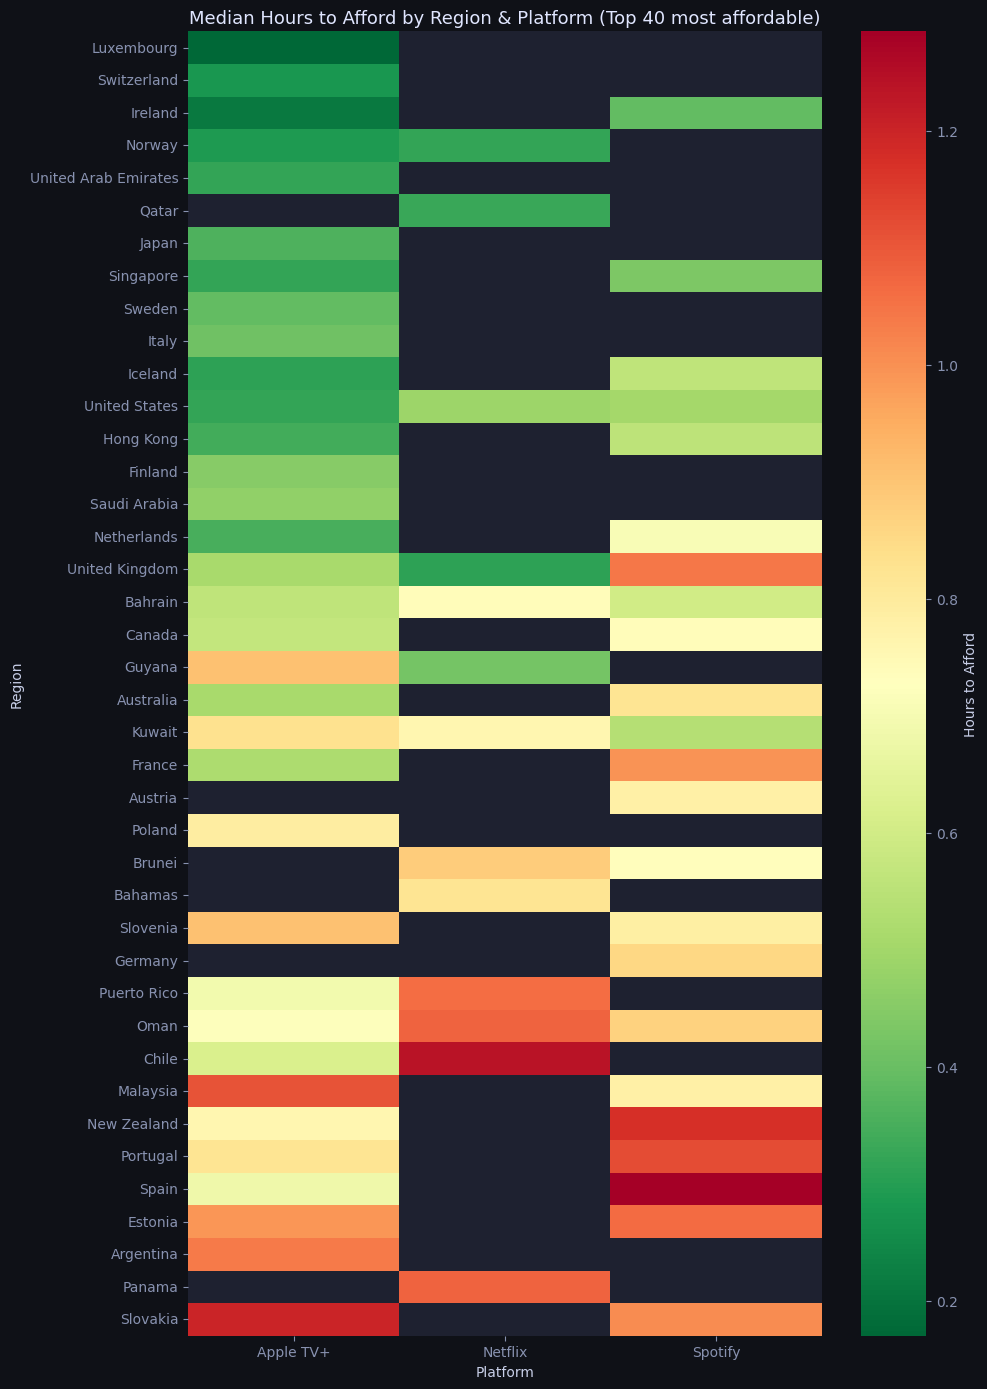

In [18]:
pivot = affordability.pivot_table(
    index="region", columns="platform", values="hours_to_afford", aggfunc="median"
).dropna(how="all")
top40 = pivot.loc[pivot.mean(axis=1).sort_values().index].head(40)
fig, ax = plt.subplots(figsize=(10, max(8, len(top40) * 0.35)))
sns.heatmap(
    top40, cmap="RdYlGn_r", annot=False, ax=ax, cbar_kws={"label": "Hours to Afford"}
)
ax.set_title("Median Hours to Afford by Region & Platform (Top 40 most affordable)")
ax.set_xlabel("Platform")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()

## 7. Steam — Price Distribution by Region

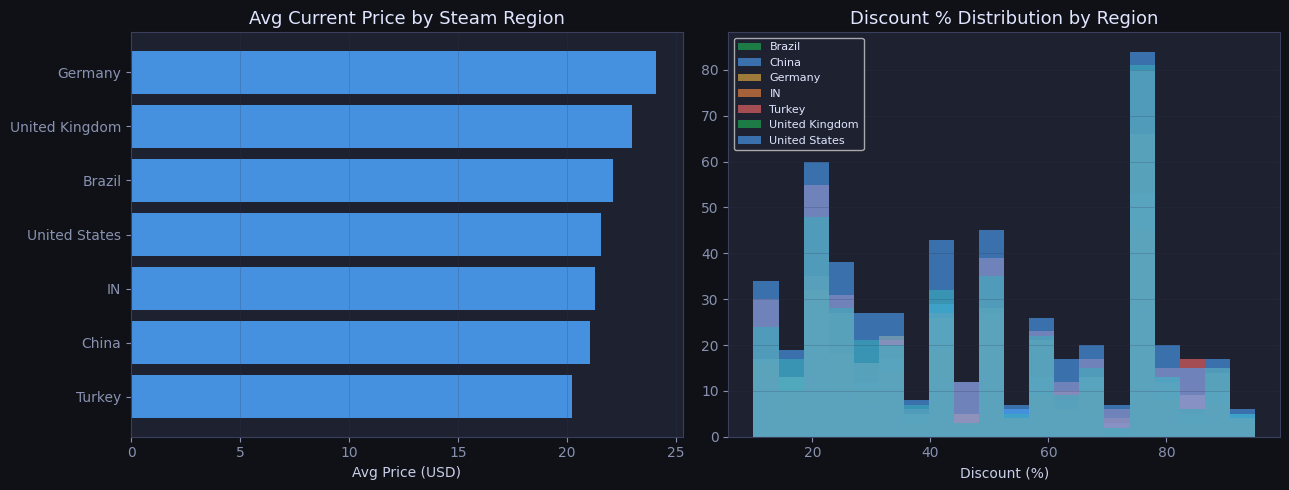

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
region_avg = steam.groupby("Region Name")["Current Price"].mean().sort_values()
axes[0].barh(region_avg.index, region_avg.values, color=ACCENT, alpha=0.85)
axes[0].set_title("Avg Current Price by Steam Region")
axes[0].set_xlabel("Avg Price (USD)")

disc = steam[steam["Discount"] < 0].copy()
disc["Disc%"] = disc["Discount"].abs()
for i, (region, grp) in enumerate(disc.groupby("Region Name")):
    axes[1].hist(
        grp["Disc%"], bins=20, alpha=0.6, label=region, color=PAL[i % len(PAL)]
    )
axes[1].set_title("Discount % Distribution by Region")
axes[1].set_xlabel("Discount (%)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(axis="x" if ax == axes[0] else "y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Steam — Top 20 Most Discounted Games

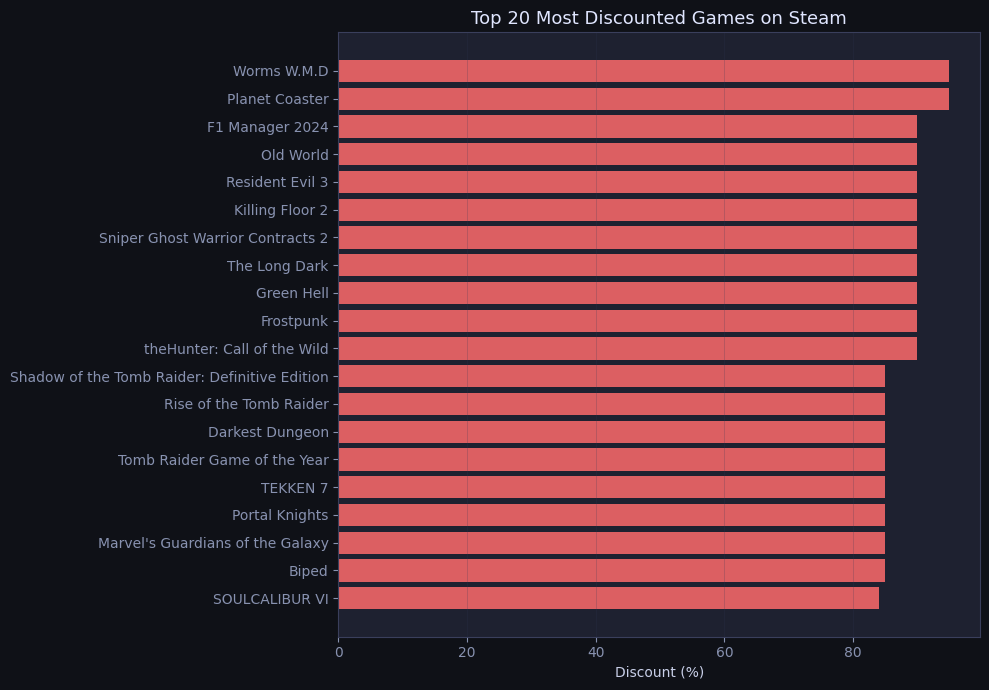

In [20]:
top20 = (
    steam[steam["Discount"] < 0]
    .copy()
    .assign(DA=lambda d: d["Discount"].abs())
    .sort_values("DA", ascending=False)
    .drop_duplicates("Title")
    .head(20)
)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20["Title"], top20["DA"], color="#FF6B6B", alpha=0.85)
ax.set_xlabel("Discount (%)")
ax.set_title("Top 20 Most Discounted Games on Steam")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Hours to Afford — Scatter: Hourly Wage vs Subscription Price

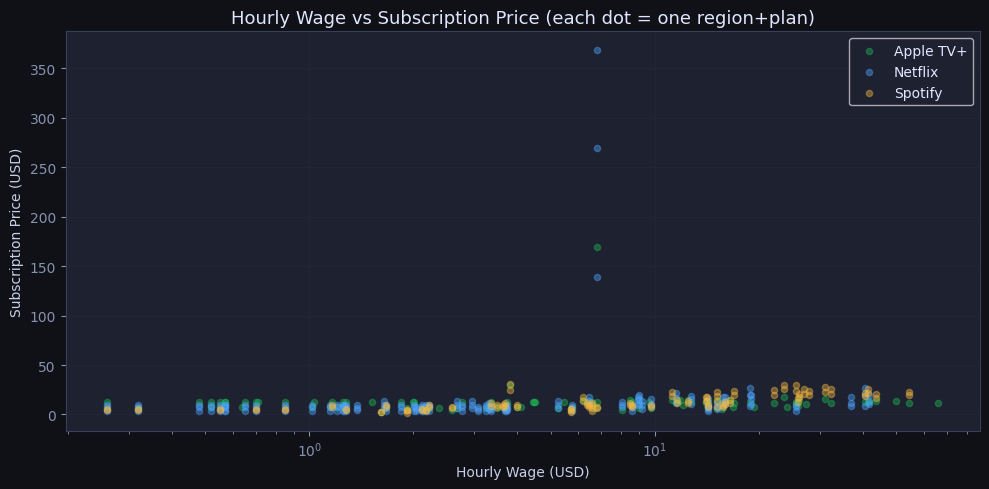

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, (plat, grp) in enumerate(affordability.groupby("platform")):
    ax.scatter(
        grp["hourly_wage_usd"],
        grp["price"],
        alpha=0.4,
        s=20,
        c=PAL[i % len(PAL)],
        label=plat,
    )
ax.set_xlabel("Hourly Wage (USD)")
ax.set_ylabel("Subscription Price (USD)")
ax.set_title("Hourly Wage vs Subscription Price (each dot = one region+plan)")
ax.set_xscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. All EDA Outputs Saved

Files written to `EDA_outputs/`:
- `Pearson_correlation_matrix.csv`
- `Descriptive_stats_per_platform.csv`
- `eda_iqr_outliers.csv` + `eda_iqr_bounds.json`
- `Hourly_wage_by_global_quartile.csv`

In [22]:
print("EDA outputs:")
for f in sorted(EDA_OUTPUT.iterdir()):
    print(f"  {f.name}")
print("\nDone! Run Machine_Learning.py and NLP_Processing.py for ML/NLP outputs.")

EDA outputs:
  Descriptive_stats_per_platform.csv
  eda_iqr_bounds.json
  eda_iqr_outliers.csv
  Hourly_wage_by_global_quartile.csv
  Pearson_correlation_matrix.csv

Done! Run Machine_Learning.py and NLP_Processing.py for ML/NLP outputs.
